In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure working directory is project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Current Working Directory: {os.getcwd()}")

# Load Artifact 1
input_artifact = 'artifacts/data/01_joined_orders.parquet'
assert os.path.exists(input_artifact), f" Artifact not found: {input_artifact}"

df = pd.read_parquet(input_artifact)
print(f" Loaded Artifact 1 successfully: {df.shape[0]:,} rows, {df.shape[1]} columns.")


Current Working Directory: c:\Users\rosto\OneDrive\سطح المكتب\مشروع mlops
 Loaded Artifact 1 successfully: 99,441 rows, 41 columns.


## 1. Order Status Analysis & Scope

In [2]:
# Inspect order statuses
status_counts = df['order_status'].value_counts()
status_pct = (df['order_status'].value_counts(normalize=True) * 100).round(2)

status_df = pd.DataFrame({'Count': status_counts, 'Percentage (%)': status_pct})
print("Order Status Distribution:")
display(status_df)

# Filter for delivered orders
delivered_df = df[df['order_status'] == 'delivered'].copy()
null_delivered_dates = delivered_df['order_delivered_customer_date'].isnull().sum()
print(f"\nTotal 'delivered' orders: {len(delivered_df):,}")
print(f"Delivered orders with missing delivery timestamp: {null_delivered_dates}")

# Drop rows with null delivered dates (only 8 rows out of 96,478)
labeled_df = delivered_df.dropna(subset=['order_delivered_customer_date']).copy()
print(f" Modeling Population: {len(labeled_df):,} orders ready for labeling.")


Order Status Distribution:


,Count,Percentage (%)
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00



Total 'delivered' orders: 96,478
Delivered orders with missing delivery timestamp: 8
 Modeling Population: 96,470 orders ready for labeling.


## 2. Constructing the Label & Delay

In [3]:
# Convert date columns to datetime
date_cols = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date']

for col in date_cols:
    labeled_df[col] = pd.to_datetime(labeled_df[col])

# Calculate delivery delay in days
labeled_df['delivery_delay_days'] = (
    labeled_df['order_delivered_customer_date'] - labeled_df['order_estimated_delivery_date']
).dt.total_seconds() / 86400.0

# Binary Label: 1 if delivered after estimated delivery date, else 0
labeled_df['is_late'] = (labeled_df['delivery_delay_days'] > 0).astype(int)

# Quick verification
print("Label creation complete. Sample values:")
labeled_df[['order_id', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'delivery_delay_days', 'is_late']].head()


Label creation complete. Sample values:


,order_id,order_estimated_delivery_date,order_delivered_customer_date,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-18,2017-10-10 21:25:13,-7.107488,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-13,2018-08-07 15:27:45,-5.355729,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-09-04,2018-08-17 18:06:29,-17.245498,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-15,2017-12-02 00:28:42,-12.980069,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-26,2018-02-16 18:17:02,-9.238171,0


## 3. Sanity Spot Checks

In [4]:
# 1. Sample of Late Orders (is_late == 1)

print(" 5 Real LATE Orders Check:")
sample_late = labeled_df[labeled_df['is_late'] == 1][
    ['order_id', 'order_purchase_timestamp', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'delivery_delay_days', 'is_late']
].sample(5, random_state=42)

for idx, row in sample_late.iterrows():
    print(f"Order: {row['order_id']}")
    print(f"  Estimated: {row['order_estimated_delivery_date']}")
    print(f"  Actual:    {row['order_delivered_customer_date']}")
    print(f"  Delay:     +{row['delivery_delay_days']:.2f} days -> is_late={row['is_late']} (CORRECT)")


 5 Real LATE Orders Check:
Order: 5077287aeb4c2ee7662411de334235ab
  Estimated: 2018-01-05 00:00:00
  Actual:    2018-01-07 12:53:38
  Delay:     +2.54 days -> is_late=1 (CORRECT)
Order: 88d845f17b3dbf8c5d642a0ffcea2e48
  Estimated: 2018-04-19 00:00:00
  Actual:    2018-04-30 22:48:43
  Delay:     +11.95 days -> is_late=1 (CORRECT)
Order: 556a854645a80f5c86ec936469f6903a
  Estimated: 2018-04-13 00:00:00
  Actual:    2018-04-18 20:57:27
  Delay:     +5.87 days -> is_late=1 (CORRECT)
Order: c887294d29ae18c8f8cdfa478a4a36b2
  Estimated: 2018-06-06 00:00:00
  Actual:    2018-06-06 19:26:46
  Delay:     +0.81 days -> is_late=1 (CORRECT)
Order: 07a8cc4e00c23ade7ccb29786d3de771
  Estimated: 2018-03-21 00:00:00
  Actual:    2018-04-04 19:04:13
  Delay:     +14.79 days -> is_late=1 (CORRECT)


In [5]:
# 2. Sample of On-Time Orders (is_late == 0)
print(" 5 Real ON-TIME Orders Check:")
sample_ontime = labeled_df[labeled_df['is_late'] == 0][
    ['order_id', 'order_purchase_timestamp', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'delivery_delay_days', 'is_late']
].sample(5, random_state=42)

for idx, row in sample_ontime.iterrows():
    print(f"Order: {row['order_id']}")
    print(f"  Estimated: {row['order_estimated_delivery_date']}")
    print(f"  Actual:    {row['order_delivered_customer_date']}")
    print(f"  Delay:     {row['delivery_delay_days']:.2f} days (Arrived early!) -> is_late={row['is_late']} (CORRECT)")


 5 Real ON-TIME Orders Check:
Order: 984b736f36379b94a92c737061fef6b4
  Estimated: 2017-05-25 00:00:00
  Actual:    2017-05-10 09:51:55
  Delay:     -14.59 days (Arrived early!) -> is_late=0 (CORRECT)
Order: 9751ad9e269564b0b79cc17a82fe06c4
  Estimated: 2017-12-06 00:00:00
  Actual:    2017-11-23 14:58:25
  Delay:     -12.38 days (Arrived early!) -> is_late=0 (CORRECT)
Order: e636e64e725aeff4955e397f34162049
  Estimated: 2018-05-25 00:00:00
  Actual:    2018-05-16 18:28:49
  Delay:     -8.23 days (Arrived early!) -> is_late=0 (CORRECT)
Order: 35572bdee2c8dfe1085aa9f6fd8ac60d
  Estimated: 2018-06-05 00:00:00
  Actual:    2018-05-22 17:22:32
  Delay:     -13.28 days (Arrived early!) -> is_late=0 (CORRECT)
Order: e28cdbb369d8571cdbe57fae21bf91c1
  Estimated: 2018-07-12 00:00:00
  Actual:    2018-06-21 23:12:57
  Delay:     -20.03 days (Arrived early!) -> is_late=0 (CORRECT)


In [6]:
# 3. Check Edge Cases: Difference between -1 and +1 days
edge_cases = labeled_df[labeled_df['delivery_delay_days'].between(-1.0, 1.0)][
    ['order_id', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'delivery_delay_days', 'is_late']
].head(5)
print(" Edge cases (within +/- 1 day of estimated date):")
edge_cases


 Edge cases (within +/- 1 day of estimated date):


,order_id,order_estimated_delivery_date,order_delivered_customer_date,delivery_delay_days,is_late
35,8563039e855156e48fccee4d611a3196,2018-03-20,2018-03-20 00:59:25,0.041262,1
78,6d25592267349b322799e2beb687871e,2018-08-30,2018-08-29 12:40:53,-0.471609,0
120,ee0c5c649e17808bc4a363d3a80ebf85,2018-02-21,2018-02-20 15:25:04,-0.357593,0
152,1d067305b599c1e0dceb3864056ea527,2018-03-09,2018-03-09 21:52:36,0.911528,1
226,c82a457d646f77c8f151e12a3e517ed2,2018-08-15,2018-08-15 15:02:09,0.626493,1


## 4. Class Imbalance Analysis

Class Distribution Summary:


,Class Name,Order Count,Percentage (%)
0,On-Time (0),88644,91.89%
1,Late (1),7826,8.11%


C:\Users\rosto\AppData\Local\Temp\ipykernel_15928\1097660014.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['On-Time (0)', 'Late (1)'], y=late_counts.values, palette=['#2ecc71', '#e74c3c'], ax=axes[0])


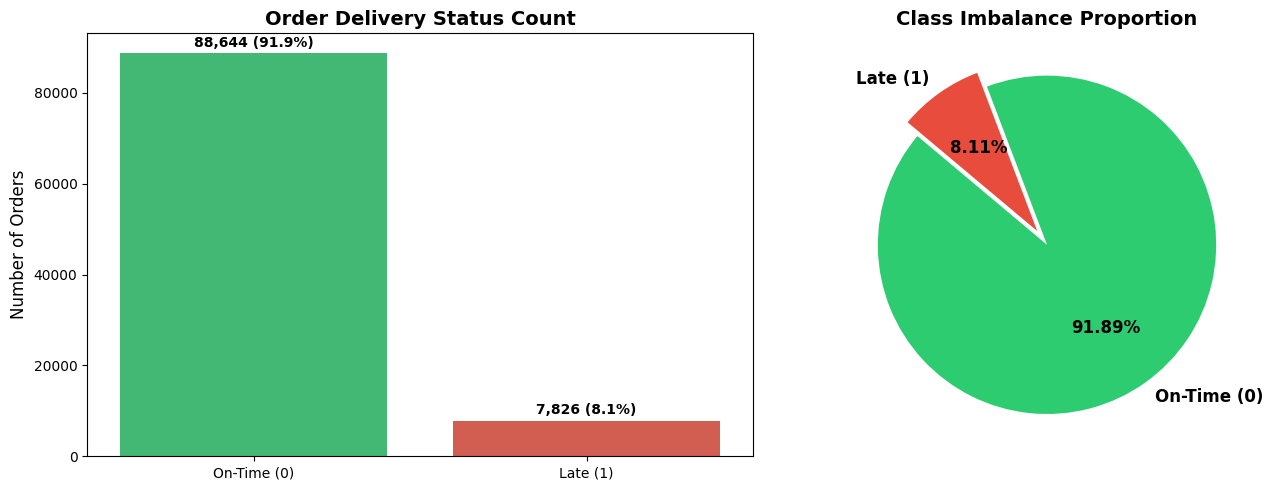

Chart saved to: artifacts/figures/class_distribution.png


In [7]:
late_counts = labeled_df['is_late'].value_counts()
late_percentages = labeled_df['is_late'].value_counts(normalize=True) * 100

class_dist_df = pd.DataFrame({
    'Class Name': ['On-Time (0)', 'Late (1)'],
    'Order Count': [late_counts[0], late_counts[1]],
    'Percentage (%)': [f"{late_percentages[0]:.2f}%", f"{late_percentages[1]:.2f}%"]})

print("Class Distribution Summary:")
display(class_dist_df)

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart
sns.barplot(x=['On-Time (0)', 'Late (1)'], y=late_counts.values, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Order Delivery Status Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Orders', fontsize=12)
for i, v in enumerate(late_counts.values):
    axes[0].text(i, v + 1500, f"{v:,} ({late_percentages.values[i]:.1f}%)", ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(
    late_counts.values, 
    labels=['On-Time (0)', 'Late (1)'], 
    autopct='%1.2f%%', 
    colors=['#2ecc71', '#e74c3c'], 
    explode=(0, 0.1),
    startangle=140,
    textprops={'fontsize': 12, 'fontweight': 'bold'})

axes[1].set_title('Class Imbalance Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
fig_path = 'artifacts/figures/class_distribution.png'
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Chart saved to: {fig_path}")


## 5. Delivery Delay Distribution

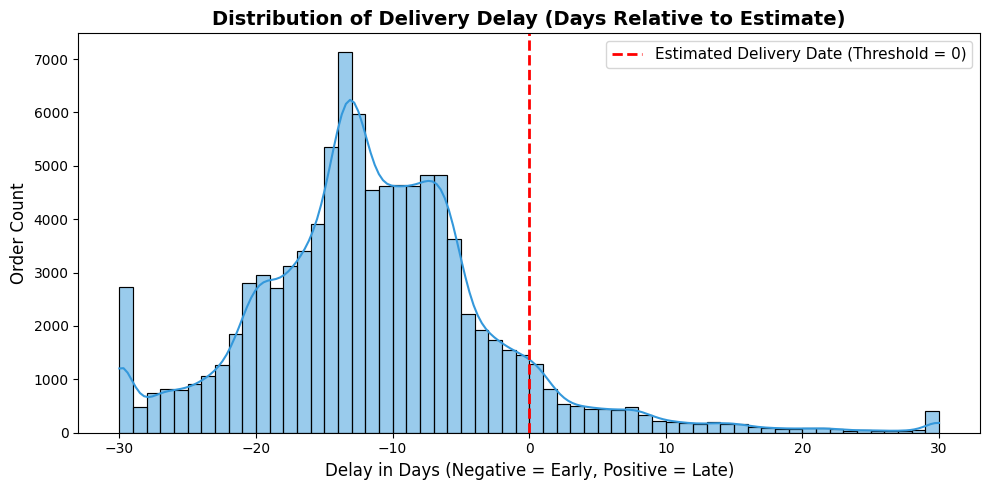

On-time orders median early arrival: 12.3 days before estimate.
Late orders median delay:             5.8 days after estimate.


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
# Filter extreme outliers for clean visualization between -30 and +30 days
delay_clipped = labeled_df['delivery_delay_days'].clip(-30, 30)

sns.histplot(delay_clipped, bins=60, kde=True, color='#3498db', ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Estimated Delivery Date (Threshold = 0)')
ax.set_title('Distribution of Delivery Delay (Days Relative to Estimate)', fontsize=14, fontweight='bold')
ax.set_xlabel('Delay in Days (Negative = Early, Positive = Late)', fontsize=12)
ax.set_ylabel('Order Count', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
fig_delay_path = 'artifacts/figures/delay_distribution.png'
plt.savefig(fig_delay_path, dpi=300)
plt.show()

# Statistics
early_stats = labeled_df[labeled_df['is_late'] == 0]['delivery_delay_days']
late_stats = labeled_df[labeled_df['is_late'] == 1]['delivery_delay_days']
print(f"On-time orders median early arrival: {abs(early_stats.median()):.1f} days before estimate.")
print(f"Late orders median delay:             {late_stats.median():.1f} days after estimate.")


## 6. Save Artifact 2

In [9]:
# Save Parquet and CSV
parquet_path = 'artifacts/data/02_labeled_orders.parquet'
csv_path = 'artifacts/data/02_labeled_orders.csv'

labeled_df.to_parquet(parquet_path, index=False)
labeled_df.to_csv(csv_path, index=False)

print(" Artifact 2 saved successfully:")


 Artifact 2 saved successfully:
